# ES vs Noise Comparison

Compare Vicuna ES results against Noise attack results using only the common query IDs.

## Summary Statistics

In [10]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
ROOT = Path('..').resolve()

def latest_results(base: Path, pattern: str) -> Path:
    runs = sorted(p for p in base.glob(pattern) if p.is_dir())
    if not runs:
        raise FileNotFoundError(f'No runs found under {base / pattern}')
    return runs[-1] / 'final_results' / 'results.csv'

def normalize_query_id(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

def parse_attack_success(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])

def load_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    print('Loaded:', path, 'Rows:', len(df))
    print('Columns:', list(df.columns))
    if 'query_id' in df.columns:
        df['query_id'] = normalize_query_id(df['query_id'])
    else:
        print('Warning: missing query_id in', path)
        df['query_id'] = ''
    if 'best_suffix' in df.columns and 'suffix' not in df.columns:
        df['suffix'] = df['best_suffix']
    required = ['query_id', 'suffix', 'fitness', 'attack_success']
    for col in required:
        if col not in df.columns:
            print('Warning: missing required column', col, 'in', path)
    print('Sample query_ids:', df['query_id'].head(5).tolist())
    return df

def load_generation_history(run_ref: Path) -> pd.DataFrame:
    run_dir = run_ref if run_ref.is_dir() else run_ref.parent.parent
    history_dir = run_dir / 'generation_history'
    if not history_dir.exists():
        print('No generation history available for', run_dir)
        return pd.DataFrame()
    frames = []
    for csv_path in sorted(history_dir.glob('*.csv')):
        hist = pd.read_csv(csv_path)
        if 'query_id' in hist.columns:
            hist['query_id'] = normalize_query_id(hist['query_id'])
        if 'generation' in hist.columns:
            hist['generation'] = pd.to_numeric(hist['generation'], errors='coerce')
        if 'best_fitness' in hist.columns:
            hist['fitness'] = pd.to_numeric(hist['best_fitness'], errors='coerce')
        elif 'fitness' in hist.columns:
            hist['fitness'] = pd.to_numeric(hist['fitness'], errors='coerce')
        if 'avg_fitness' in hist.columns:
            hist['avg_fitness'] = pd.to_numeric(hist['avg_fitness'], errors='coerce')
        if 'attack_success' in hist.columns:
            hist['attack_success'] = parse_attack_success(hist['attack_success'])
        elif 'jailbroken_count' in hist.columns:
            hist['attack_success'] = pd.to_numeric(hist['jailbroken_count'], errors='coerce').fillna(0) > 0
        frames.append(hist)
    if not frames:
        print('No usable generation history found for', run_dir)
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    if 'generation' not in out.columns:
        print('Generation data missing in history for', run_dir)
        return pd.DataFrame()
    out = out.dropna(subset=['generation'])
    out['generation'] = out['generation'].astype(int)
    return out

es_path = latest_results(ROOT / 'outputs' / 'vicuna_7b', 'run_*')
noise_path = latest_results(ROOT / 'outputs' / 'noise_attack', 'run_*')
es = load_results(es_path)
noise = load_results(noise_path)

common = set(es['query_id']) & set(noise['query_id'])
print('Common queries:', len(common))
es = es[es['query_id'].isin(common)].copy()
noise = noise[noise['query_id'].isin(common)].copy()
es = es.sort_values('query_id').reset_index(drop=True)
noise = noise.sort_values('query_id').reset_index(drop=True)
assert all(es['query_id'] == noise['query_id'])

es['fitness'] = pd.to_numeric(es['fitness'], errors='coerce')
noise['fitness'] = pd.to_numeric(noise['fitness'], errors='coerce')
es['attack_success_bool'] = parse_attack_success(es['attack_success'])
noise['attack_success_bool'] = parse_attack_success(noise['attack_success'])

valid_mask = es['fitness'].notna() & noise['fitness'].notna()
es = es[valid_mask].reset_index(drop=True)
noise = noise[valid_mask].reset_index(drop=True)

es_success = es['attack_success_bool'].mean()
noise_success = noise['attack_success_bool'].mean()

print('\n=== ALGORITHM COMPARISON ===')
print('Final ES rows:', len(es))
print('Final Noise rows:', len(noise))
print('ES success:', es_success)
print('Noise success:', noise_success)
print('ES avg fitness:', es['fitness'].mean())
print('Noise avg fitness:', noise['fitness'].mean())

summary = pd.DataFrame({
    'method': ['ES', 'Noise'],
    'success_rate': [es_success, noise_success],
    'avg_fitness': [es['fitness'].mean(), noise['fitness'].mean()],
    'success_count': [es['attack_success_bool'].sum(), noise['attack_success_bool'].sum()],
})
display(summary)

es_history = load_generation_history(es_path)
noise_history = load_generation_history(noise_path)

if 'generation' not in es_history.columns or 'generation' not in noise_history.columns:
    print('Generation data missing')
    common_gen = []
    es_best = pd.Series(dtype=float)
    noise_best = pd.Series(dtype=float)
    es_avg_gen = pd.Series(dtype=float)
    noise_avg_gen = pd.Series(dtype=float)
    es_success_gen = pd.Series(dtype=float)
    noise_success_gen = pd.Series(dtype=float)
else:
    common_gen = sorted(set(es_history['generation']) & set(noise_history['generation']))
    es_g = es_history[es_history['generation'].isin(common_gen)].copy()
    noise_g = noise_history[noise_history['generation'].isin(common_gen)].copy()
    es_best = es_g.groupby('generation')['fitness'].max()
    noise_best = noise_g.groupby('generation')['fitness'].max()
    if 'avg_fitness' in es_g.columns and 'avg_fitness' in noise_g.columns:
        es_avg_gen = es_g.groupby('generation')['avg_fitness'].mean()
        noise_avg_gen = noise_g.groupby('generation')['avg_fitness'].mean()
    else:
        es_avg_gen = es_g.groupby('generation')['fitness'].mean()
        noise_avg_gen = noise_g.groupby('generation')['fitness'].mean()
    es_success_gen = es_g.groupby('generation')['attack_success'].mean() if 'attack_success' in es_g.columns else pd.Series(dtype=float)
    noise_success_gen = noise_g.groupby('generation')['attack_success'].mean() if 'attack_success' in noise_g.columns else pd.Series(dtype=float)
    print('Common generations:', len(common_gen))

Loaded: D:\Study\Python\DS\llm\autodan-evo\outputs\vicuna_7b\run_20260408_200524\final_results\results.csv Rows: 252
Columns: ['timestamp', 'query_id', 'category', 'model_name', 'query', 'best_suffix', 'fitness', 'attack_score', 'alignment_score', 'readability_score', 'avg_eval_time', 'attack_success', 'baseline_jailbroken', 'length_score', 'generation_reached', 'total_runtime_s', 'best_response']
Sample query_ids: ['1', '2', '3', '4', '5']
Loaded: D:\Study\Python\DS\llm\autodan-evo\outputs\noise_attack\run_20260407_023225\final_results\results.csv Rows: 269
Columns: ['timestamp', 'query_id', 'category', 'model_name', 'query', 'best_suffix', 'fitness', 'attack_score', 'alignment_score', 'readability_score', 'avg_eval_time', 'attack_success', 'baseline_jailbroken', 'length_score', 'generation_reached', 'total_runtime_s', 'best_response']
Sample query_ids: ['1', '2', '3', '4', '5']
Common queries: 252

=== ALGORITHM COMPARISON ===
Final ES rows: 252
Final Noise rows: 252
ES success: 0.99

,method,success_rate,avg_fitness,success_count
0,ES,0.992063,0.781089,250
1,Noise,0.944444,0.841146,238


Common generations: 15


## Visualization

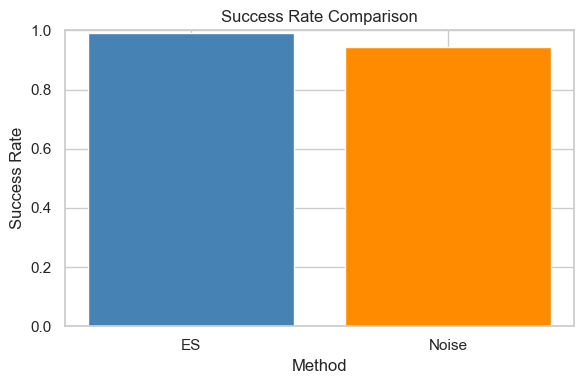

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(['ES', 'Noise'], [es_success, noise_success], color=['steelblue', 'darkorange'])
plt.title('Success Rate Comparison')
plt.xlabel('Method')
plt.ylabel('Success Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

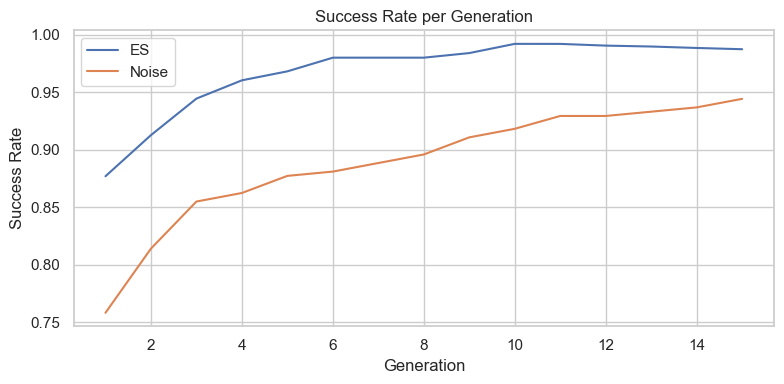

In [12]:
if es_success_gen.empty or noise_success_gen.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_success_gen.index, es_success_gen.values, label='ES')
    plt.plot(noise_success_gen.index, noise_success_gen.values, label='Noise')
    plt.xlabel('Generation')
    plt.ylabel('Success Rate')
    plt.title('Success Rate per Generation')
    plt.legend()
    plt.tight_layout()
    plt.show()

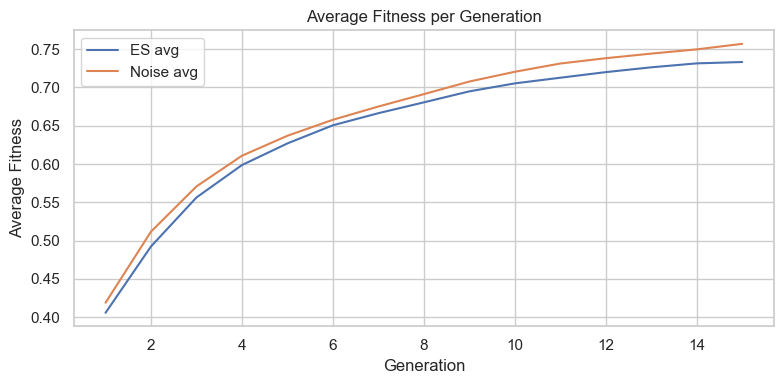

In [13]:
if es_avg_gen.empty or noise_avg_gen.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_avg_gen.index, es_avg_gen.values, label='ES avg')
    plt.plot(noise_avg_gen.index, noise_avg_gen.values, label='Noise avg')
    plt.xlabel('Generation')
    plt.ylabel('Average Fitness')
    plt.title('Average Fitness per Generation')
    plt.legend()
    plt.tight_layout()
    plt.show()

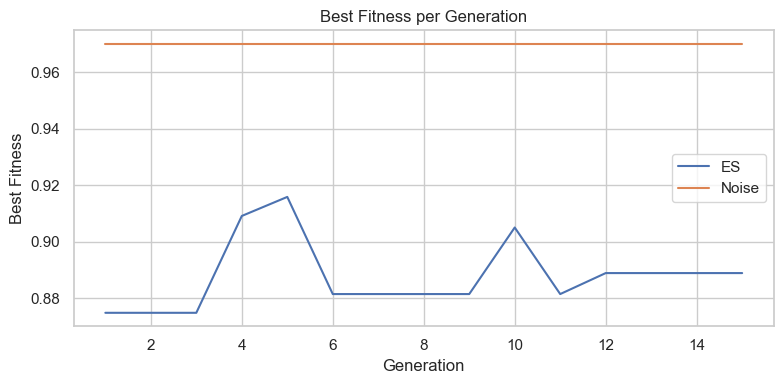

In [14]:
if es_best.empty or noise_best.empty:
    print('Generation data missing')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(es_best.index, es_best.values, label='ES')
    plt.plot(noise_best.index, noise_best.values, label='Noise')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.title('Best Fitness per Generation')
    plt.legend()
    plt.tight_layout()
    plt.show()

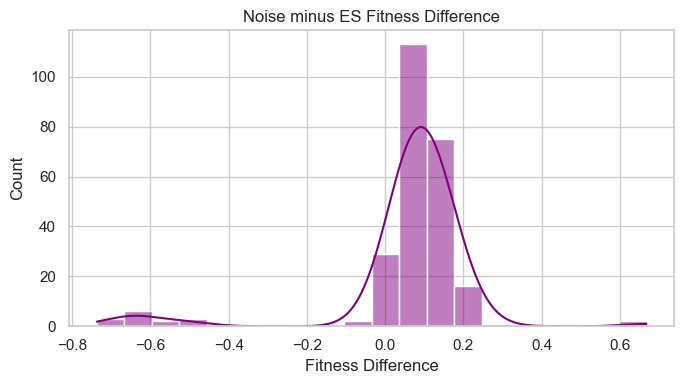

In [15]:
diff = noise['fitness'].to_numpy() - es['fitness'].to_numpy()
plt.figure(figsize=(7, 4))
sns.histplot(diff, bins=20, kde=True, color='purple')
plt.title('Noise minus ES Fitness Difference')
plt.xlabel('Fitness Difference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

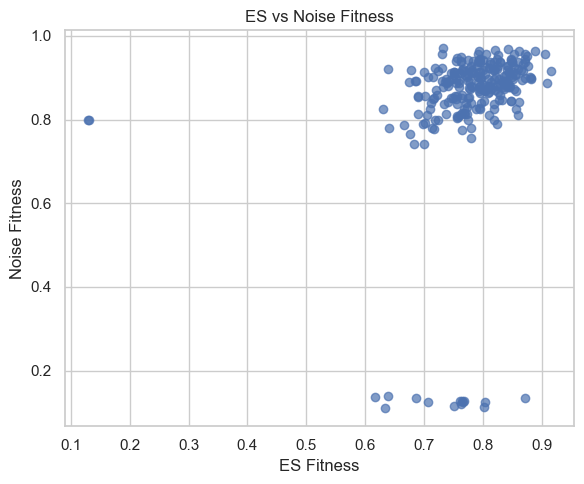

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(es['fitness'], noise['fitness'], alpha=0.7)
plt.xlabel('ES Fitness')
plt.ylabel('Noise Fitness')
plt.title('ES vs Noise Fitness')
plt.tight_layout()
plt.show()

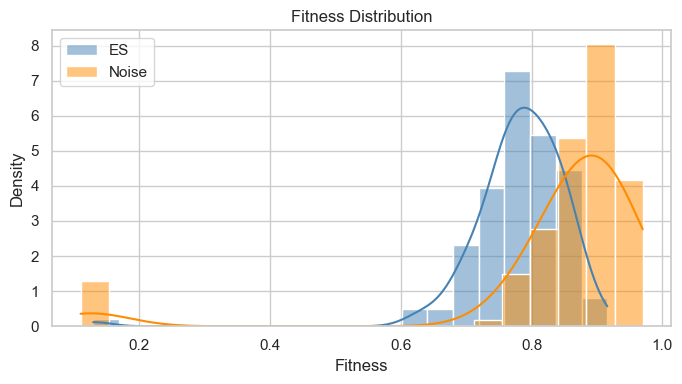

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(es['fitness'], label='ES', kde=True, stat='density', bins=20, color='steelblue', alpha=0.5)
sns.histplot(noise['fitness'], label='Noise', kde=True, stat='density', bins=20, color='darkorange', alpha=0.5)
plt.legend()
plt.title('Fitness Distribution')
plt.xlabel('Fitness')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Interpretation

- Which method converges faster? Compare the generation-level fitness curves.
- Which achieves higher peak fitness? Inspect the best-fitness trajectory and the scatter plot.
- Is optimization stable or noisy? Compare the average fitness and success-rate trajectories over generations.
- Does success appear early or late? Look for the generation where the success-rate curve first rises.